# Masked image modeling: reconstruct missing patches

Runnable locally on CPU or on a Cloud TPU VM.

- Preserve patch order and pixel order
- Keep hidden pixels out of the encoder
- Verify the changed-condition exercise and explain the limits of this fixture.

If part of an image is hidden, can the model infer it from visible patches? The important question is whether hidden pixels are truly absent from the encoder, not whether the reconstruction looks attractive.

## The idea

Masked image modeling learns from visible image content to predict missing content. To understand the objective, distinguish observed patches, hidden targets and predicted values in the original image coordinates.

## Keep hidden patches in their spatial positions

The fixture splits a four-by-four image into four two-by-two patches in row-major order. Patches $0$ and $3$ are visible; $1$ and $2$ are hidden. Show hidden regions with hatching so they cannot be mistaken for observed black pixels.

The implemented reconstructor is linear: eight visible pixel values plus a constant feature map through a nine-by-sixteen weight matrix. It is a deliberately small mechanism example, not a masked autoencoder Transformer.

Compare target and predicted hidden patches at the same spatial coordinates and on a shared intensity scale. A separate error map reveals remaining mistakes that a small average loss can hide. Changing a hidden target without changing visible input must not change the model's forward input.

### Visible patches and hidden targets

**Predict:** Why should original and reconstructed images share a color scale?

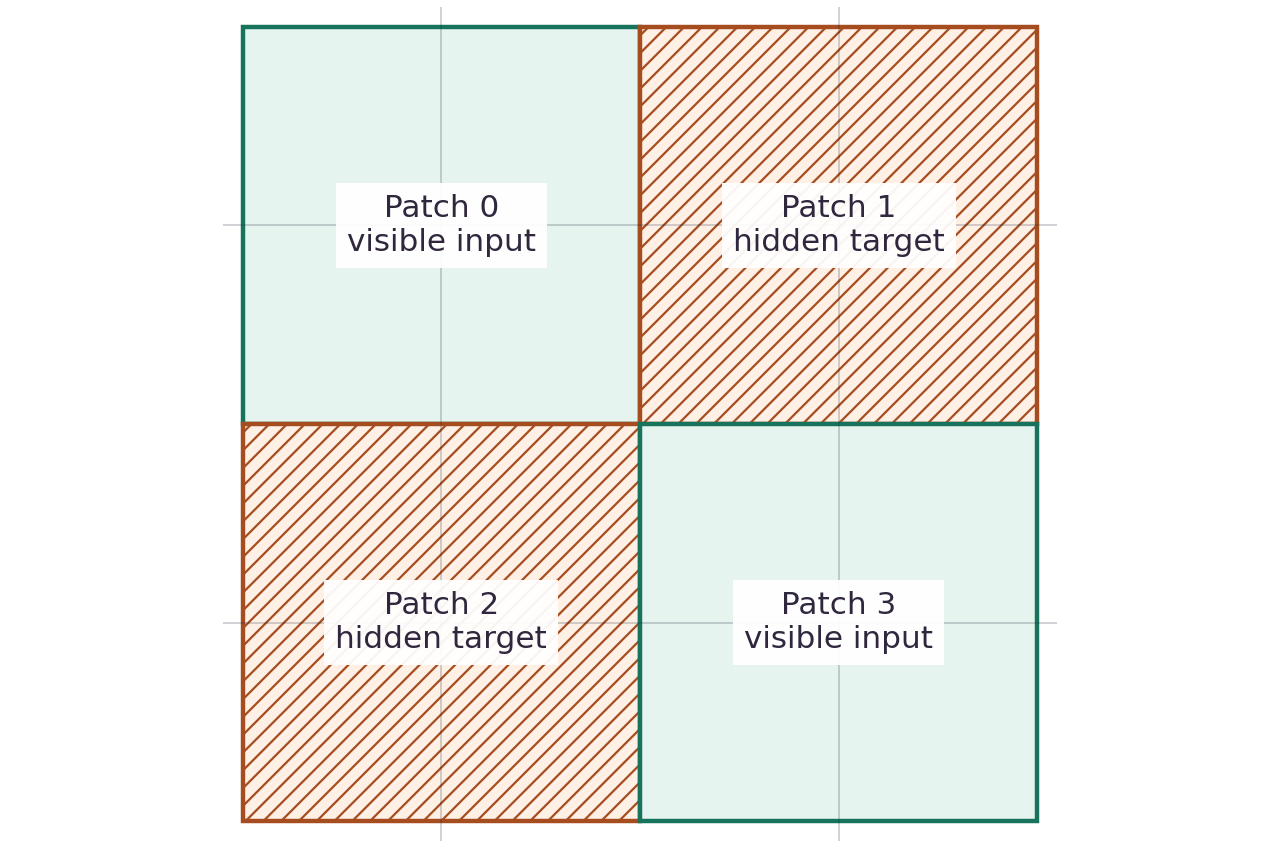

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

The sixteen cells preserve the four-by-four image layout. Green patches 0 and 3 provide visible values. Hatched patches 1 and 2 are hidden targets for reconstruction loss. Hatching means missing input, not observed black pixels. This maps the actual mask without inventing a reconstructed image or error measurement.

### Pause and reason

Why should original and reconstructed images share a color scale?

<details><summary>Compare your reasoning</summary>

Independent scaling can make different intensities look equal. A shared scale preserves visual comparison; the error map should have its own clearly labeled scale.

</details>

## Before coding: what information can the model use?

Imagine covering the top-right and bottom-left quarters of a small image. The model is allowed to see the other two quarters and must infer the covered pixels. Keep two separate paths on your sketch: visible patches go into features, while the untouched image supplies targets. A zero loss is suspicious if the target image is also an encoder input.

This dataset varies a single brightness amplitude on top of a fixed spatial pattern. Visible pixels reveal that amplitude, so a linear map can succeed. That makes the example suitable for auditing masking and patch order, but it cannot teach natural-image representation quality on its own.

## Preserve patch order and pixel order

Images use batch, height, width, channel axes. A $4\times4$ single-channel image becomes four $2\times2$ patches with four scalars each. Reshape alone does not generally produce row-major patch order; transpose the grid and within-patch axes deliberately. The first patch is checked against an independently sliced image region.

## Keep hidden pixels out of the encoder

Gather visible patches before constructing features. The clean full image belongs only to the reconstruction target. In a masked autoencoder, a visible-only encoder can reduce encoder work while a decoder uses position information and mask tokens to restore the complete patch ordering. Our linear decoder has an explicit output coordinate for each patch/pixel, so it has a fixed positional contract without a Transformer.

## Work through a patch rather than memorizing reshape

Number a single-channel image row by row from $0$ through $15$. Its top-left patch is $[0,1,4,5]$, not $[0,1,2,3]$. The latter is a horizontal strip caused by flattening without the grid-axis transpose. For general image shape $(B,H,W,C)$ and patch width $p$, the output shape is $(B,HW/p^2,p^2C)$. The channel coordinate remains inside each pixel.

In our fixture, two visible patches each contribute four pixels; appending a bias gives nine features. The decoder has sixteen outputs because it predicts every patch coordinate. Its visible outputs are unconstrained by the hidden-only objective. A whole-image picture should therefore show a composite that preserves visible input pixels and inserts predictions only where hidden.

## Understand which uncertainty the objective can solve

If two examples have exactly the same visible pixels but different hidden targets, no deterministic model can reconstruct both perfectly. For a scalar target equally likely to be $0$ or $2$, the mean-squared-error optimum is $1$, with average squared error $1$. The result looks like neither original target. More capacity cannot recover information absent from the inputs.

This explains why blurry reconstructions need not mean an implementation bug. First check information flow, patch layout and the irreducible ambiguity of the data; then investigate capacity or optimization. A useful downstream representation must be tested separately from pixel reconstruction.

## Reduce over the hidden reconstruction targets

First average squared pixel error within each patch, then sum the hidden-patch errors and divide by the hidden count. This definition gives equal weight to every hidden pixel because all patches have equal size. Errors on visible outputs are excluded. Mixing visible and hidden pixels can flatter the score when copying visible inputs is easy.

$$
L=\frac{\sum_{b,k}m_{bk}\,\frac1P\sum_{j=1}^{P}(\widehat x_{bkj}-x_{bkj})^2}{\sum_{b,k}m_{bk}}
$$

## Interpret normalization and reconstruction

Raw-pixel reconstruction and per-patch normalized reconstruction are different objectives. Normalization can remove a patch’s brightness/contrast information and requires a clear inverse or evaluation convention. This lesson uses raw synthetic values and records MSE in squared input units. Do not compare that number directly with a differently normalized experiment.

## Evaluate beyond the training mask

The reference checks intermediate amplitudes that were not training examples. That is a small interpolation test, not semantic recognition. For transfer, freeze the encoder and train a probe on separate labels, or fine-tune under a held-out protocol. Compare mask ratios with fixed compute/data budgets and keep all-hidden or all-visible policies explicit.

## Make a transfer test that can falsify your explanation

Our held-out amplitudes test interpolation under the same fixed spatial pattern. They do not test new mask layouts. Changing the visible positions while keeping the same feature coordinate meanings silently changes the model contract. A variable-mask encoder needs positions and a visible-token gathering/restoration scheme.

Before claiming a transferable image encoder, test new source images, compare a frozen probe and fine-tuning with a matched baseline, and inspect class-specific failures. In this lesson, keep a simpler evidence packet: a numbered patch oracle, a hidden-pixel intervention, an ambiguity example, a composite reconstruction, and a written explanation of which of these tests would catch leakage.

## 1. Define patch layout and masked error

Create main.py in your activated course environment. Paste this block, then run python main.py; function definitions alone print nothing.

In [1]:
# Step 1 — 1. Define patch layout and masked error: Trace the transpose against the numbered top-left patch.
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Function `patchify(images, patch)` implementing this stage's computation:
def patchify(images, patch=2):
    # Compute `b, h, w, c` from `images.shape`
    b, h, w, c = images.shape
    # Guard input contract (`h % patch or w % patch`) and fail fast if violated.
    if h % patch or w % patch:
        raise ValueError('image dimensions must be divisible by patch size')
    # Return `images.reshape(b, h // patch, patch, w // patch, patch, c).transpose(0, 1, 3, 2, 4, 5).reshape(b, h // patch * (w // patch), patch * patch * c)` to the caller.
    return (
        images.reshape(b, h // patch, patch, w // patch, patch, c)
        .transpose(0, 1, 3, 2, 4, 5)
        .reshape(b, (h // patch) * (w // patch), patch * patch * c)
    )

# Function `masked_mse(prediction, target, hidden)` implementing this stage's computation:
def masked_mse(prediction, target, hidden):
    # Reduce along axis=-1 to compute `per_patch`.
    per_patch = jnp.mean((prediction - target) ** 2, axis=-1)
    # Return `jnp.sum(jnp.where(hidden, per_patch, 0.0)) / jnp.sum(hidden)` to the caller.
    return jnp.sum(jnp.where(hidden, per_patch, 0.0)) / jnp.sum(hidden)

# Function `validate_mask(selected, shape)` implementing this stage's computation:
def validate_mask(selected, shape):
    # Convert `a` to a host NumPy array for inspection or verification.
    a = np.asarray(selected)
    # Guard input contract (`a.shape != shape or a.dtype != np.bool_ or (not a.any())`) and fail fast if violated.
    if a.shape != shape or a.dtype != np.bool_ or not a.any():
        raise ValueError('a nonempty Boolean mask of the target shape is required')

Trace the transpose against the numbered top-left patch. masked_mse gives equal weight to each hidden pixel only because every patch has equal size.

## 2. Separate visible features from full targets

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [2]:
# Four patches share an amplitude plus a fixed spatial offset; no real photographs.
amplitude = jnp.array([0.1, 0.3, 0.6, 0.8])
# Construct and reshape `base_image` into the target tensor dimensions.
base_image = jnp.arange(16, dtype=jnp.float32).reshape(4, 4, 1) / 32
# Compute `images` from `amplitude[:, None, None, None] + base_image[None]`
images = amplitude[:, None, None, None] + base_image[None]
# Run `patchify` to compute `patches`.
patches = patchify(images)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_array_equal(patches[0, 0], np.asarray(images[0, :2, :2, :]).reshape(-1))
# Construct `hidden` via `jnp.array([[False, True, True, False]] * 4)`
hidden = jnp.array([[False, True, True, False]] * 4)
# Run `validate_mask` to perform the next check or state transition.
validate_mask(hidden, patches.shape[:2])
# The encoder receives only visible patches; original hidden pixels are targets only.
visible = patches[:, [0, 3], :]
# Construct and reshape `features` into the target tensor dimensions.
features = jnp.concatenate([visible.reshape(4, -1), jnp.ones((4, 1))], axis=1)
# Construct `w` via `jnp.zeros((9, 16))`
w = jnp.zeros((9, 16))
# Compute `history` from `[]`
history = []
# Construct and reshape `loss` into the target tensor dimensions.
loss = lambda w: masked_mse((features @ w).reshape(4, 4, 4), patches, hidden)
# Differentiate the objective to obtain `step` via automatic differentiation.
step = jax.jit(jax.value_and_grad(loss))

Only patches $0$ and $3$ enter features. The bias permits a spatial offset; hidden pixels remain solely in patches, the target array.

## 3. Fit the decoder and audit the reconstruction

Append this block to main.py and run python main.py again. Keep the earlier blocks above it.

In [3]:
# Step 3 — 3. Fit the decoder and audit the reconstruction: The host loop checks the reduction independently.
for _ in range(100):
    # Run `step` to compute `(value, g)`.
    value, g = step(w)
    # Append the current step result to `history`.
    history.append(float(value))
    # Compute `w` from `w - 0.15 * g`
    w = w - 0.15 * g

# Construct and reshape `prediction` into the target tensor dimensions.
prediction = (features @ w).reshape(4, 4, 4)
# Assert invariant `history[-1] < history[0] * 0.02` holds
assert history[-1] < history[0] * 0.02
# A scalar host loop is independent of the vectorized reduction.
expected = np.mean(
    [
        float(np.mean((np.asarray(prediction[b, k]) - np.asarray(patches[b, k])) ** 2))
        for b in range(4)
        for k in [1, 2]
    ]
)
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(loss(w), expected, rtol=1e-5)`
np.testing.assert_allclose(loss(w), expected, rtol=1e-5)
# Compute `visible_changed` from `prediction.at[:, [0, 3], :].set(999.0)`
visible_changed = prediction.at[:, [0, 3], :].set(999.0)
# Execute `np.testing.assert_allclose(`
np.testing.assert_allclose(
    masked_mse(visible_changed, patches, hidden), loss(w), atol=1e-7
)
# Construct `held_images` via `jnp.array([0.2, 0.5])[:, None, None, None] + base_im...`
held_images = jnp.array([0.2, 0.5])[:, None, None, None] + base_image[None]
# Run `patchify` to compute `held_patches`.
held_patches = patchify(held_images)
# Construct and reshape `held_features` into the target tensor dimensions.
held_features = jnp.concatenate(
    [held_patches[:, [0, 3], :].reshape(2, -1), jnp.ones((2, 1))], axis=1
)
# Construct and reshape `held_loss` into the target tensor dimensions.
held_loss = float(
    masked_mse((held_features @ w).reshape(2, 4, 4), held_patches, hidden[:2])
)
# Assert invariant `held_loss < 0.02` holds
assert held_loss < 0.02
# Print diagnostic summary of the computed outputs.
print(
    'Masked pixel MSE initial/final/held amplitudes:',
    history[0],
    history[-1],
    held_loss,
)

Masked pixel MSE initial/final/held amplitudes: 0.5538085699081421 0.0016928859986364841 0.0011766081443056464


The host loop checks the reduction independently. Corrupting visible outputs checks the loss boundary; held amplitudes check a narrow interpolation claim.

## Run the example

In [4]:
# Step 1 — 1. Define patch layout and masked error: Trace the transpose against the numbered top-left patch.
# Import jax for this computation.
import jax
import jax.numpy as jnp
import numpy as np

# Function `patchify(images, patch)` implementing this stage's computation:
def patchify(images, patch=2):
    # Compute `b, h, w, c` from `images.shape`
    b, h, w, c = images.shape
    # Guard input contract (`h % patch or w % patch`) and fail fast if violated.
    if h % patch or w % patch:
        raise ValueError('image dimensions must be divisible by patch size')
    # Return `images.reshape(b, h // patch, patch, w // patch, patch, c).transpose(0, 1, 3, 2, 4, 5).reshape(b, h // patch * (w // patch), patch * patch * c)` to the caller.
    return (
        images.reshape(b, h // patch, patch, w // patch, patch, c)
        .transpose(0, 1, 3, 2, 4, 5)
        .reshape(b, (h // patch) * (w // patch), patch * patch * c)
    )

# Function `masked_mse(prediction, target, hidden)` implementing this stage's computation:
def masked_mse(prediction, target, hidden):
    # Reduce along axis=-1 to compute `per_patch`.
    per_patch = jnp.mean((prediction - target) ** 2, axis=-1)
    # Return `jnp.sum(jnp.where(hidden, per_patch, 0.0)) / jnp.sum(hidden)` to the caller.
    return jnp.sum(jnp.where(hidden, per_patch, 0.0)) / jnp.sum(hidden)

# Function `validate_mask(selected, shape)` implementing this stage's computation:
def validate_mask(selected, shape):
    # Convert `a` to a host NumPy array for inspection or verification.
    a = np.asarray(selected)
    # Guard input contract (`a.shape != shape or a.dtype != np.bool_ or (not a.any())`) and fail fast if violated.
    if a.shape != shape or a.dtype != np.bool_ or not a.any():
        raise ValueError('a nonempty Boolean mask of the target shape is required')

# Four patches share an amplitude plus a fixed spatial offset; no real photographs.
amplitude = jnp.array([0.1, 0.3, 0.6, 0.8])
# Construct and reshape `base_image` into the target tensor dimensions.
base_image = jnp.arange(16, dtype=jnp.float32).reshape(4, 4, 1) / 32
# Compute `images` from `amplitude[:, None, None, None] + base_image[None]`
images = amplitude[:, None, None, None] + base_image[None]
# Run `patchify` to compute `patches`.
patches = patchify(images)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_array_equal(patches[0, 0], np.asarray(images[0, :2, :2, :]).reshape(-1))
# Construct `hidden` via `jnp.array([[False, True, True, False]] * 4)`
hidden = jnp.array([[False, True, True, False]] * 4)
# Run `validate_mask` to perform the next check or state transition.
validate_mask(hidden, patches.shape[:2])
# The encoder receives only visible patches; original hidden pixels are targets only.
visible = patches[:, [0, 3], :]
# Construct and reshape `features` into the target tensor dimensions.
features = jnp.concatenate([visible.reshape(4, -1), jnp.ones((4, 1))], axis=1)
# Construct `w` via `jnp.zeros((9, 16))`
w = jnp.zeros((9, 16))
# Compute `history` from `[]`
history = []
# Construct and reshape `loss` into the target tensor dimensions.
loss = lambda w: masked_mse((features @ w).reshape(4, 4, 4), patches, hidden)
# Differentiate the objective to obtain `step` via automatic differentiation.
step = jax.jit(jax.value_and_grad(loss))

# Step 3 — 3. Fit the decoder and audit the reconstruction: The host loop checks the reduction independently.
for _ in range(100):
    # Run `step` to compute `(value, g)`.
    value, g = step(w)
    # Append the current step result to `history`.
    history.append(float(value))
    # Compute `w` from `w - 0.15 * g`
    w = w - 0.15 * g

# Construct and reshape `prediction` into the target tensor dimensions.
prediction = (features @ w).reshape(4, 4, 4)
# Assert invariant `history[-1] < history[0] * 0.02` holds
assert history[-1] < history[0] * 0.02
# A scalar host loop is independent of the vectorized reduction.
expected = np.mean(
    [
        float(np.mean((np.asarray(prediction[b, k]) - np.asarray(patches[b, k])) ** 2))
        for b in range(4)
        for k in [1, 2]
    ]
)
# Check numerical equivalence within tolerance: `np.testing.assert_allclose(loss(w), expected, rtol=1e-5)`
np.testing.assert_allclose(loss(w), expected, rtol=1e-5)
# Compute `visible_changed` from `prediction.at[:, [0, 3], :].set(999.0)`
visible_changed = prediction.at[:, [0, 3], :].set(999.0)
# Execute `np.testing.assert_allclose(`
np.testing.assert_allclose(
    masked_mse(visible_changed, patches, hidden), loss(w), atol=1e-7
)
# Construct `held_images` via `jnp.array([0.2, 0.5])[:, None, None, None] + base_im...`
held_images = jnp.array([0.2, 0.5])[:, None, None, None] + base_image[None]
# Run `patchify` to compute `held_patches`.
held_patches = patchify(held_images)
# Construct and reshape `held_features` into the target tensor dimensions.
held_features = jnp.concatenate(
    [held_patches[:, [0, 3], :].reshape(2, -1), jnp.ones((2, 1))], axis=1
)
# Construct and reshape `held_loss` into the target tensor dimensions.
held_loss = float(
    masked_mse((held_features @ w).reshape(2, 4, 4), held_patches, hidden[:2])
)
# Assert invariant `held_loss < 0.02` holds
assert held_loss < 0.02
# Print diagnostic summary of the computed outputs.
print(
    'Masked pixel MSE initial/final/held amplitudes:',
    history[0],
    history[-1],
    held_loss,
)

Masked pixel MSE initial/final/held amplitudes: 0.5538085699081421 0.0016928859986364841 0.0011766081443056464


Expected: Hidden-patch training MSE falls below 0.002 and held-amplitude MSE stays below 0.02.

## Masked image modeling: reconstruct missing patches — recorded experiment

Predict: Will every predicted pixel match its target exactly? Which output patches were never trained?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Masked image modeling: reconstruct missing patches — recorded experiment
# Compute `visual_data` from `{'kind':'line','xlabel':'completed parameter updates...`
visual_data={'kind':'line','xlabel':'completed parameter updates before measurement','ylabel':'hidden-pixel MSE (squared input units)','series':[{'label':'recorded CPU training loss','x':list(range(len(history))),'y':history}]}
# Loop over `panel` in `visual_data.get('panels', [visual_data])`:
for panel in visual_data.get('panels',[visual_data]):
    # Compute `panel['x']` from `panel['series'][0]['x']`
    panel['x']=panel['series'][0]['x']

# Convert `patch_comparison` to a host NumPy array for inspection or verification.
patch_comparison=np.concatenate([np.asarray(patches[0,[1,2],:]),np.asarray(prediction[0,[1,2],:])],axis=0)
# Compute `extra_panel` from `{'kind':'heatmap','values':patch_comparison.tolist()...`
extra_panel={'kind':'heatmap','values':patch_comparison.tolist(),'rows':['target patch 1','target patch 2','predicted patch 1','predicted patch 2'],'columns':['pixel 0','pixel 1','pixel 2','pixel 3'],'unit':'raw pixel value','xlabel':'within-patch pixel order','ylabel':'hidden patch and source','title':'Hidden targets and final predictions for the first image'}
# Compute `visual_data` from `{"panels":[*visual_data.get("panels",[visual_data]),...`
visual_data={"panels":[*visual_data.get("panels",[visual_data]),extra_panel]}

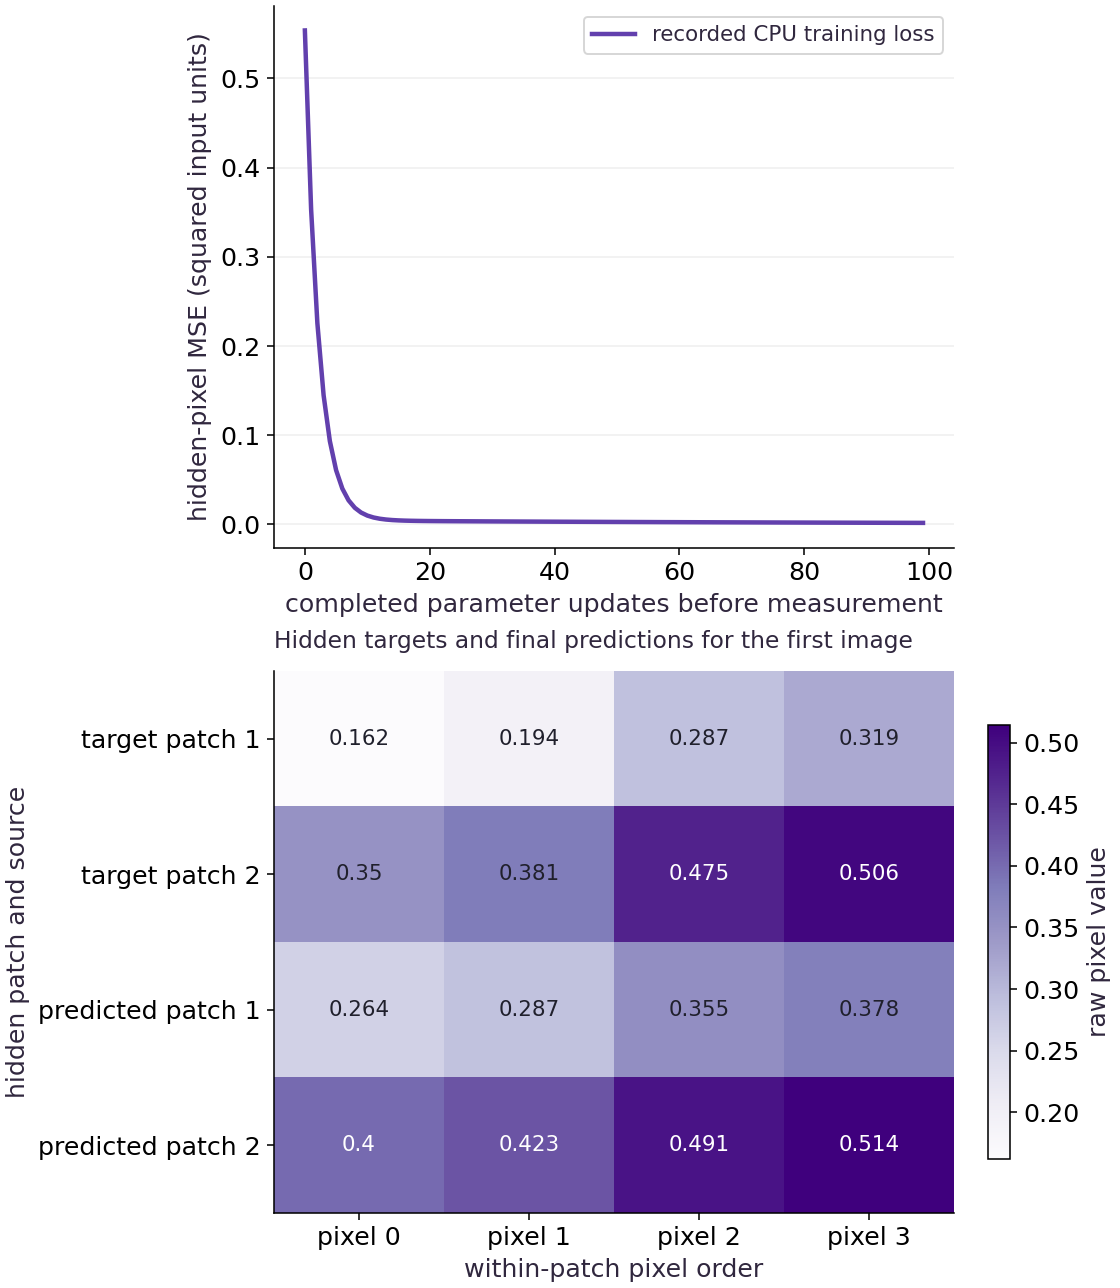

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The line shows hidden-patch training MSE before each update, falling from about $0.554$ to $0.00169$. The vertical units are squared raw pixel units. The line excludes visible-patch reconstruction errors; it cannot be read as full-image MSE.

The second panel inspects the first image only. Its first two rows are clean hidden-patch targets; the last two are final predictions in the same within-patch order. Compare row one with row three and row two with row four, rather than looking for a diagonal. Residual brightness differences explain why the training MSE is small but nonzero. Visible outputs are omitted because this loss never trains them; displaying them as a full reconstructed image would be misleading.

### Connect it to the computation

Each image contains an amplitude and a fixed spatial pattern. Visible patches reveal the amplitude, so a linear decoder can infer hidden pixels on this deliberately learnable task. Separate held-amplitude MSE is approximately 0.00118. Natural-image semantics and a visible-token Transformer remain different experiments.

## Make visible-output errors arbitrarily large

Predict: Will visible-output corruption raise the hidden-patch objective?

In [7]:
# Experiment — Make visible-output errors arbitrarily large: The disagreement identifies the reduction contract.
bad_visible = prediction.at[:, [0, 3], :].set(-1000.0)
# Execute `np.testing.assert_allclose(`
np.testing.assert_allclose(
    masked_mse(bad_visible, patches, hidden),
    masked_mse(prediction, patches, hidden),
)
# Assert invariant `float(jnp.mean((bad_visible - patches) ** 2)) > 1000` holds
assert float(jnp.mean((bad_visible - patches) ** 2)) > 1000
# Print the observed values to compare against the expected result.
print('Hidden MSE unchanged; full-image MSE is large.')

Hidden MSE unchanged; full-image MSE is large.


Expected: Hidden MSE stays unchanged while full-image MSE grows dramatically.

The disagreement identifies the reduction contract. Neither metric is universally correct; label which region and preprocessing it measures.

## Make hidden information impossible to recover

Predict: Can any deterministic prediction have zero MSE for two identical inputs with hidden targets zero and two?

In [8]:
# Experiment — Make hidden information impossible to recover: The experiment isolates missing information.
# Construct `ambiguous_targets` via `jnp.array([[[0.0]], [[2.0]]])`
ambiguous_targets = jnp.array([[[0.0]], [[2.0]]])
# Construct `ambiguous_mask` via `jnp.ones((2, 1), dtype=bool)`
ambiguous_mask = jnp.ones((2, 1), dtype=bool)

# Function `ambiguity_loss(value)` implementing this stage's computation:
def ambiguity_loss(value):
    # Return `masked_mse(jnp.full_like(ambiguous_targets, value), ambiguous_targets, ambiguous_mask)` to the caller.
    return masked_mse(
        jnp.full_like(ambiguous_targets, value), ambiguous_targets, ambiguous_mask
    )

# Execute `np.testing.assert_allclose(`
np.testing.assert_allclose(
    [ambiguity_loss(0.0), ambiguity_loss(1.0), ambiguity_loss(2.0)], [2.0, 1.0, 2.0]
)
# Differentiate the objective to obtain gradients ``.
np.testing.assert_allclose(jax.grad(ambiguity_loss)(1.0), 0.0, atol=1e-7)
# Print the observed values to compare against the expected result.
print('Ambiguous target MSE at predictions 0, 1, 2: 2, 1, 2')

Ambiguous target MSE at predictions 0, 1, 2: 2, 1, 2


Expected: Predicting the mean is optimal but still leaves MSE of one.

The experiment isolates missing information. A loss plateau can be caused by ambiguity even when gradients and optimization are correct.

## Your exercise

Verify the bottom-right patch against a direct slice and explain why a whole-array reshape can hide a spatial permutation.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).

**Step-by-step implementation plan:**
1. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Verify the bottom-right patch against a direct slice and explain why a...
np.testing.assert_array_equal(
    patches[2, 3], np.asarray(images[2, 2:, 2:, :]).reshape(-1)
)
# Print the observed values to compare against the expected result.
print('Bottom-right patch order verified.')
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Verify the bottom-right patch against a direct slice and explain why a...
# np.testing.assert_array_equal(
#     patches[2, 3], np.asarray(images[2, 2:, 2:, :]).reshape(-1)
# )
# Print the observed values to compare against the expected result.
# print('Bottom-right patch order verified.')

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Verify the bottom-right patch against a direct slice and explain why a...
np.testing.assert_array_equal(
    patches[2, 3], np.asarray(images[2, 2:, 2:, :]).reshape(-1)
)
# Print the observed values to compare against the expected result.
print('Bottom-right patch order verified.')

Bottom-right patch order verified.


## Expose the leakage shortcut · Transfer

Compare a decoder that returns the clean target with the visible-only model. Explain why zero reconstruction loss is not sufficient evidence.

Hint: Measure the shortcut, then inspect which function inputs contain hidden pixels.

### How to write: Expose the leakage shortcut — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `shortcut(...)` — Call `shortcut` with your updated parameters or inputs from this lesson's workspace.
- `masked_mse(...)` — Call `masked_mse` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Assert invariant `float(masked_mse(shortcut, patches, hidden)) == 0.0` holds
2. Check tensor shape invariant: `features.shape[1] == 9`
3. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Expose the leakage shortcut (Transfer): An information-flow check is necessary because the leaked...
shortcut = ...  # TODO: compute shortcut
# Assert invariant `float(masked_mse(shortcut, patches, hidden)) == 0.0` holds
assert float(masked_mse(shortcut, patches, hidden))  # TODO: complete assertion check
# Check tensor shape invariant: `features.shape[1] == 9`
assert features.shape[1]  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('The zero-loss shortcut receives hidden pixels; the real features contain only eight visible pixels and a bias.')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Expose the leakage shortcut (Transfer): An information-flow check is necessary because the leaked...
# shortcut = ...  # TODO: compute shortcut
# Assert invariant `float(masked_mse(shortcut, patches, hidden)) == 0.0` holds
# assert float(masked_mse(shortcut, patches, hidden))  # TODO: complete assertion check
# Check tensor shape invariant: `features.shape[1] == 9`
# assert features.shape[1]  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('The zero-loss shortcut receives hidden pixels; the real features contain only eight visible pixels and a bias.')

## Reference reasoning

An information-flow check is necessary because the leaked solution can outperform the honest model on the objective itself.

In [12]:
# Expose the leakage shortcut (Transfer): An information-flow check is necessary because the leaked...
shortcut = patches
# Assert invariant `float(masked_mse(shortcut, patches, hidden)) == 0.0` holds
assert float(masked_mse(shortcut, patches, hidden)) == 0.0
# Check tensor shape invariant: `features.shape[1] == 9`
assert features.shape[1] == 9
# Print the observed values to compare against the expected result.
print('The zero-loss shortcut receives hidden pixels; the real features contain only eight visible pixels and a bias.')

The zero-loss shortcut receives hidden pixels; the real features contain only eight visible pixels and a bias.


## Audit every patch of a rectangular color image · Challenge

Construct two 4-by-6 RGB images with numbered entries. Compare patchify with an independent nested slicing oracle for every patch, then change hidden pixels and prove visible features stay fixed.

Hint: Use explicit image slices inside the oracle; do not copy the reshape/transpose implementation.

### How to write: Audit every patch of a rectangular color image — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `array.reshape(new_shape)` — Reorganizes tensor axes without changing the total element count (`array.size`).

**Step-by-step implementation plan:**
1. Construct and reshape `numbered` into the target tensor dimensions.
2. Construct and reshape `oracle` into the target tensor dimensions.
3. Create device-backed JAX array ``.
4. Compute `changed_images` from `images.at[:, :2, 2:, :].add(17.0).at[:, 2:, :2, :].a...`
5. Run `patchify` to compute `changed_patches`.

**Starter code scaffold (fill in the TODOs):**

```python
# Audit every patch of a rectangular color image (Challenge): The rectangular multichannel case catches axis errors that a...
# Construct and reshape `numbered` into the target tensor dimensions.
numbered = np.arange(...)  # TODO: compute numbered
# Construct and reshape `oracle` into the target tensor dimensions.
oracle = np.stack(...)  # TODO: compute oracle
    [
        np.stack(
            [
                image[row : row + 2, col : col + 2, :].reshape(-1)
                for row in range(0, 4, 2)
                for col in range(0, 6, 2)
            ]
        )
        for image in numbered
    ]
)
# Create device-backed JAX array ``.
np.testing.assert_array_equal(patchify(jnp.asarray(numbered)), oracle)
# Compute `changed_images` from `images.at[:, :2, 2:, :].add(17.0).at[:, 2:, :2, :].a...`
changed_images = ...  # TODO: compute changed_images
# Run `patchify` to compute `changed_patches`.
changed_patches = patchify(...)  # TODO: compute changed_patches
# Execute `np.testing.assert_array_equal(changed_patches[:, [0, 3], :],`
np.testing.assert_array_equal(changed_patches[:, [0, 3], :], visible)
# Assert invariant `not np.array_equal(` holds
assert not np.array_equal(  # TODO: complete assertion check
    np.asarray(changed_patches[:, [1, 2], :]), np.asarray(patches[:, [1, 2], :])
)
# Print the observed values to compare against the expected result.
print('All rectangular RGB patches agree; hidden-pixel intervention preserves visible features.')
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Audit every patch of a rectangular color image (Challenge): The rectangular multichannel case catches axis errors that a...
# Construct and reshape `numbered` into the target tensor dimensions.
# numbered = np.arange(...)  # TODO: compute numbered
# Construct and reshape `oracle` into the target tensor dimensions.
# oracle = np.stack(...)  # TODO: compute oracle
#     [
#         np.stack(
#             [
#                 image[row : row + 2, col : col + 2, :].reshape(-1)
#                 for row in range(0, 4, 2)
#                 for col in range(0, 6, 2)
#             ]
#         )
#         for image in numbered
#     ]
# )
# Create device-backed JAX array ``.
# np.testing.assert_array_equal(patchify(jnp.asarray(numbered)), oracle)
# Compute `changed_images` from `images.at[:, :2, 2:, :].add(17.0).at[:, 2:, :2, :].a...`
# changed_images = ...  # TODO: compute changed_images
# Run `patchify` to compute `changed_patches`.
# changed_patches = patchify(...)  # TODO: compute changed_patches
# Execute `np.testing.assert_array_equal(changed_patches[:, [0, 3], :],`
# np.testing.assert_array_equal(changed_patches[:, [0, 3], :], visible)
# Assert invariant `not np.array_equal(` holds
# assert not np.array_equal(  # TODO: complete assertion check
#     np.asarray(changed_patches[:, [1, 2], :]), np.asarray(patches[:, [1, 2], :])
# )
# Print the observed values to compare against the expected result.
# print('All rectangular RGB patches agree; hidden-pixel intervention preserves visible features.')

## Reference reasoning

The rectangular multichannel case catches axis errors that a single square grayscale patch can miss. The intervention independently checks that hidden targets cannot enter this encoder.

In [14]:
# Audit every patch of a rectangular color image (Challenge): The rectangular multichannel case catches axis errors that a...
# Construct and reshape `numbered` into the target tensor dimensions.
numbered = np.arange(2 * 4 * 6 * 3, dtype=np.float32).reshape(2, 4, 6, 3)
# Construct and reshape `oracle` into the target tensor dimensions.
oracle = np.stack(
    [
        np.stack(
            [
                image[row : row + 2, col : col + 2, :].reshape(-1)
                for row in range(0, 4, 2)
                for col in range(0, 6, 2)
            ]
        )
        for image in numbered
    ]
)
# Create device-backed JAX array ``.
np.testing.assert_array_equal(patchify(jnp.asarray(numbered)), oracle)
# Compute `changed_images` from `images.at[:, :2, 2:, :].add(17.0).at[:, 2:, :2, :].a...`
changed_images = images.at[:, :2, 2:, :].add(17.0).at[:, 2:, :2, :].add(-9.0)
# Run `patchify` to compute `changed_patches`.
changed_patches = patchify(changed_images)
# Execute `np.testing.assert_array_equal(changed_patches[:, [0, 3], :],`
np.testing.assert_array_equal(changed_patches[:, [0, 3], :], visible)
# Assert invariant `not np.array_equal(` holds
assert not np.array_equal(
    np.asarray(changed_patches[:, [1, 2], :]), np.asarray(patches[:, [1, 2], :])
)
# Print the observed values to compare against the expected result.
print('All rectangular RGB patches agree; hidden-pixel intervention preserves visible features.')

All rectangular RGB patches agree; hidden-pixel intervention preserves visible features.


## Checkpoint

Why must the encoder input be inspected separately from reconstruction loss?

1. A leaked target can produce a perfect loss without learning to infer missing content.
2. Averaging squared error over only hidden patches automatically prevents hidden pixels from entering the encoder.
3. Flattening an image without transposing grid and patch axes changes the shape of the patch tensor.

## Diagnose

If reconstruction is excellent before learning, inspect target leakage. If patches look shuffled, verify the patch transpose and decoder restoration order. If metrics differ, compare the mask count and normalization.

## Evidence

Keep patch-order slices, visible-only feature shapes, hidden-patch counts, independent MSE and held-amplitude reconstruction results.

## Carry forward

- Verify patch extraction against an explicit spatial slice: converting $(B,H,W,C)$ into $(B,HW/p^2,p^2C)$ requires transposing the grid and within-patch axes before flattening.
- Keep hidden patches out of the encoder feature tensor and reduce reconstruction MSE over the hidden mask only; changing hidden target values must never alter the encoder forward input.

## Primary references

- [Masked Autoencoders](https://arxiv.org/abs/2111.06377)